<div align="center">

# 04 · Model Evaluation

### Production Quality Drift Detector


</div>


In [5]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [6]:
def find_data_file(filename):
    paths = [
        Path.cwd() / "Data" / filename,
        Path.cwd().parent / "Data" / filename
    ]

    for path in paths:
        if path.is_file():
            return path.resolve()

    raise FileNotFoundError(f"{filename} was not found in the project Data folder.")

DATA_PATH = find_data_file("Data_drift_results.csv")
df = pd.read_csv(DATA_PATH)

print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")


Loaded: D:\Sarthak's Folder\Project\Hackathon\Data\Data_drift_results.csv
Shape: 14,992 rows × 109 columns


In [7]:
def normalize_name(name):
    name = str(name).strip().lower()
    name = re.sub(r"[%/()\-]+", "_", name)
    name = re.sub(r"[^a-z0-9_]+", "_", name)
    return re.sub(r"_+", "_", name).strip("_")

ALIASES = {
    "batch_id": ["batch_id", "batch", "batch_number", "batch_no", "lot_id", "lot_number"],
    "timestamp": ["timestamp", "datetime", "date_time", "date", "recorded_at", "recorded_time"],
    "machine_id": ["machine_id", "machine", "machine_no", "machine_number", "equipment_id"],
    "product_line": ["product_line", "production_line", "line", "line_id", "product"],
    "temperature": ["temperature", "temp", "temp_c", "temperature_c", "temperature_celsius"],
    "pressure": ["pressure", "press", "pressure_psi", "pressure_bar"],
    "cycle_time": ["cycle_time", "cycle_duration", "cycle_time_sec", "duration", "processing_time"],
    "vibration": ["vibration", "vibration_level", "vibration_mm_s", "vibration_rms"],
    "quality_measurement": ["quality_measurement", "quality_score", "quality", "quality_index"],
    "defect_rate": ["defect_rate", "defect_percentage", "defect_pct", "defect_ratio"],
    "actual_status": ["actual_status", "status", "process_status", "quality_status", "condition"],
    "final_outcome": ["final_outcome", "outcome", "result", "final_result", "decision"],
    "temperature_tolerance": ["temperature_tolerance", "temp_tolerance", "temperature_limit", "temp_limit"],
    "pressure_tolerance": ["pressure_tolerance", "pressure_limit", "pressure_upper_limit"],
    "cycle_time_tolerance": ["cycle_time_tolerance", "cycle_tolerance", "cycle_time_limit"],
    "vibration_tolerance": ["vibration_tolerance", "vibration_limit", "vibration_upper_limit"]
}

def detect_column(concept):
    normalized = {normalize_name(c): c for c in df.columns}
    for alias in ALIASES.get(concept, []):
        key = normalize_name(alias)
        if key in normalized:
            return normalized[key]
    return None

COLUMN_MAP = {concept: detect_column(concept) for concept in ALIASES}
display(pd.DataFrame([{"concept": k, "column": v or "NOT FOUND"} for k, v in COLUMN_MAP.items()]))


,concept,column
0,batch_id,batch_id
1,timestamp,timestamp
2,machine_id,machine_id
3,product_line,product_line
4,temperature,temperature
5,pressure,pressure
6,cycle_time,cycle_time
7,vibration,vibration
8,quality_measurement,quality_measurement
9,defect_rate,defect_rate


# 01 · Find Ground Truth

In [8]:
GROUND_TRUTH_ALIASES = [
    "drift_label",
    "drift",
    "scripted_drift",
    "ground_truth",
    "actual_drift",
    "is_drift",
    "drift_ground_truth"
]

normalized = {normalize_name(c): c for c in df.columns}
ground_truth_col = None

for alias in GROUND_TRUTH_ALIASES:
    if normalize_name(alias) in normalized:
        ground_truth_col = normalized[normalize_name(alias)]
        break

print(f"Ground truth column: {ground_truth_col or 'NOT FOUND'}")


Ground truth column: NOT FOUND


# 02 · Find Detector Output

In [9]:
detected_col = "detected_status" if "detected_status" in df.columns else None
score_col = "drift_score" if "drift_score" in df.columns else None

print(f"Status output: {detected_col or 'NOT FOUND'}")
print(f"Score output: {score_col or 'NOT FOUND'}")

if not detected_col and not score_col:
    raise ValueError("No drift detector output exists in the results dataset.")


Status output: detected_status
Score output: drift_score


# 03 · Convert Ground Truth to Binary

In [10]:
def to_binary_truth(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(int)

    numeric = pd.to_numeric(series, errors="coerce")

    if numeric.notna().mean() >= 0.90:
        return (numeric > 0).astype(int)

    positive = {
        "1", "true", "yes", "y", "drift",
        "anomaly", "abnormal", "critical", "warning"
    }

    values = series.astype("string").str.strip().str.lower()
    return values.isin(positive).astype(int)

if ground_truth_col:
    df["actual_drift"] = to_binary_truth(df[ground_truth_col])
    display(df["actual_drift"].value_counts().sort_index().to_frame("count"))
else:
    print("No ground truth available.")


No ground truth available.


# 04 · Convert Detector Output

In [11]:
if detected_col:
    df["predicted_drift"] = (
        df[detected_col]
        .astype("string")
        .str.strip()
        .str.lower()
        .isin(["warning", "critical"])
        .astype(int)
    )
else:
    df["predicted_drift"] = (df[score_col] >= 0.30).astype(int)

display(df["predicted_drift"].value_counts().sort_index().to_frame("count"))


,count
predicted_drift,
0,13438
1,1554


# 05 · Classification Metrics

In [12]:
if ground_truth_col:
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

    y_true = df["actual_drift"]
    y_pred = df["predicted_drift"]

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) else 0

    metrics = pd.DataFrame({
        "metric": [
            "accuracy", "precision", "recall", "f1",
            "false_positive_rate", "true_positive", "false_positive",
            "false_negative", "true_negative"
        ],
        "value": [
            accuracy, precision, recall, f1, fpr, tp, fp, fn, tn
        ]
    })

    display(metrics.round(4))
    print(classification_report(
        y_true,
        y_pred,
        target_names=["No Drift", "Drift"],
        zero_division=0
    ))
else:
    metrics = pd.DataFrame()
    print("Ground truth unavailable. Supervised metrics skipped.")


Ground truth unavailable. Supervised metrics skipped.


# 06 · Confusion Matrix

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

if ground_truth_col:
    cm = confusion_matrix(df["actual_drift"], df["predicted_drift"], labels=[0, 1])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["No Drift", "Drift"],
        yticklabels=["No Drift", "Drift"]
    )
    plt.title("Drift Detection Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
else:
    print("Ground truth unavailable.")


Ground truth unavailable.


# 07 · Detection Delay


In [14]:
if ground_truth_col:
    actual_indices = df.index[df["actual_drift"] == 1].tolist()
    predicted_indices = df.index[df["predicted_drift"] == 1].tolist()

    if actual_indices:
        onset = actual_indices[0]
        detections = [i for i in predicted_indices if i >= onset]

        if detections:
            first_detection = detections[0]
            detection_delay = first_detection - onset
            print(f"Drift onset observation: {onset}")
            print(f"First detection observation: {first_detection}")
            print(f"Detection delay: {detection_delay} observations")
        else:
            detection_delay = np.nan
            print("No detection after drift onset.")
    else:
        detection_delay = np.nan
        print("No positive drift period found.")
else:
    detection_delay = np.nan
    print("Detection delay requires ground truth.")


Detection delay requires ground truth.


# 08 · Variable-Level Evidence

In [15]:
variable_score_cols = [
    c for c in df.columns
    if c.endswith("_drift_score")
    and c not in {"process_drift_score", "drift_score"}
]

if variable_score_cols:
    variable_report = pd.DataFrame({
        "variable": [c.replace("_drift_score", "") for c in variable_score_cols],
        "mean_drift_score": [df[c].mean() for c in variable_score_cols],
        "max_drift_score": [df[c].max() for c in variable_score_cols],
        "high_score_observations": [int((df[c] >= 0.60).sum()) for c in variable_score_cols]
    }).sort_values("mean_drift_score", ascending=False)

    display(variable_report.round(4))
else:
    variable_report = pd.DataFrame()
    print("No variable-level scores found.")


,variable,mean_drift_score,max_drift_score,high_score_observations
1,pressure,0.3202,0.6667,53
0,temperature,0.2214,0.6667,32
3,vibration,0.0514,0.6667,31
2,cycle_time,0.0487,0.6667,15


# 09 · Evaluation Timeline

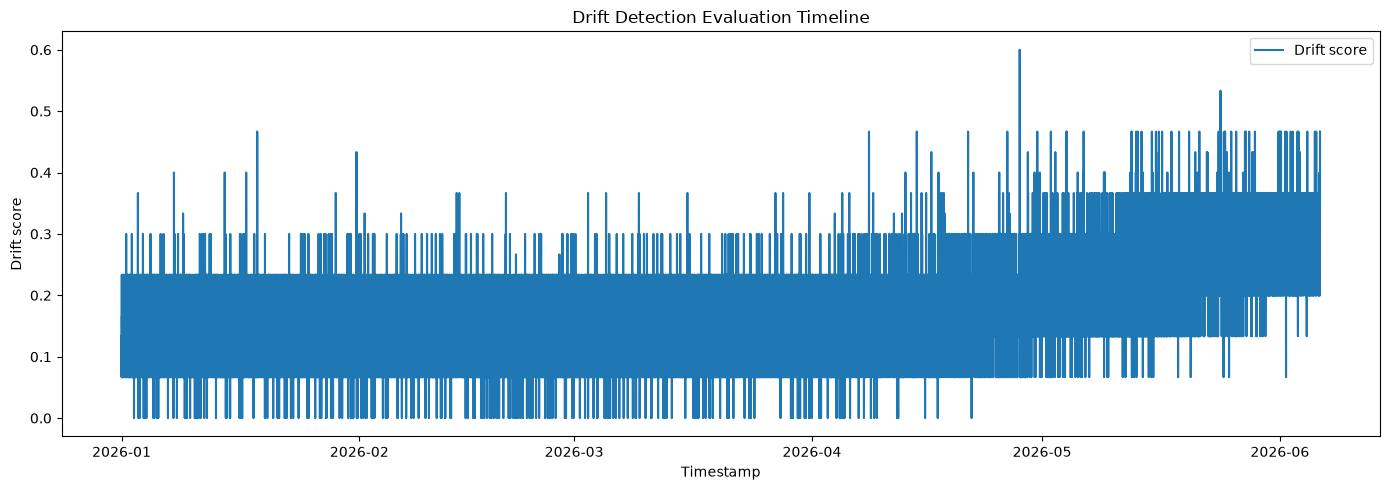

In [16]:
timestamp_col = COLUMN_MAP.get("timestamp")

x = (
    pd.to_datetime(df[timestamp_col], errors="coerce")
    if timestamp_col and timestamp_col in df.columns
    else np.arange(len(df))
)

plt.figure(figsize=(14, 5))

if score_col:
    plt.plot(x, df[score_col], label="Drift score")

if ground_truth_col and df["actual_drift"].any():
    mask = df["actual_drift"] == 1
    level = df[score_col].max() if score_col else 1
    plt.scatter(x[mask], np.full(mask.sum(), level), marker="x", s=35, label="Actual drift")

plt.title("Drift Detection Evaluation Timeline")
plt.xlabel("Timestamp" if timestamp_col else "Production sequence")
plt.ylabel("Drift score")
plt.legend()
plt.tight_layout()
plt.show()


# 10 · Evaluation Summary

In [17]:
print("=" * 72)
print("PRODUCTION QUALITY DRIFT DETECTOR — EVALUATION")
print("=" * 72)

if ground_truth_col:
    print(f"Ground truth: {ground_truth_col}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"False Positive Rate: {fpr:.4f}")
    print(
        "Detection delay:",
        detection_delay if not pd.isna(detection_delay) else "Not detected"
    )
else:
    print("Ground truth: NOT AVAILABLE")
    print("Supervised performance metrics cannot be calculated from this dataset.")


PRODUCTION QUALITY DRIFT DETECTOR — EVALUATION
Ground truth: NOT AVAILABLE
Supervised performance metrics cannot be calculated from this dataset.


# 11 · Export Evaluation Reports

In [18]:
data_dir = DATA_PATH.parent

evaluation_summary = pd.DataFrame({
    "ground_truth_available": [bool(ground_truth_col)],
    "ground_truth_column": [ground_truth_col or ""],
    "detector_output": [detected_col or score_col or ""],
    "accuracy": [accuracy if ground_truth_col else np.nan],
    "precision": [precision if ground_truth_col else np.nan],
    "recall": [recall if ground_truth_col else np.nan],
    "f1": [f1 if ground_truth_col else np.nan],
    "false_positive_rate": [fpr if ground_truth_col else np.nan],
    "detection_delay_observations": [detection_delay]
})

summary_path = data_dir / "drift_evaluation_summary.csv"
evaluation_summary.to_csv(summary_path, index=False)

if not metrics.empty:
    metrics.to_csv(data_dir / "drift_evaluation_metrics.csv", index=False)

if not variable_report.empty:
    variable_report.to_csv(data_dir / "drift_variable_report.csv", index=False)

print(f"Saved: {summary_path}")


Saved: D:\Sarthak's Folder\Project\Hackathon\Data\drift_evaluation_summary.csv
